# Randomforest - Diabetes

In [4]:
 #Gerekli kütüphaneler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Makine öğrenimi
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import (mean_squared_error, r2_score,
                             accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer

# Görsel ayarlar
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print("✅ Tüm kütüphaneler başarıyla içe aktarıldı.")


# Download latest version
path = kagglehub.dataset_download("pritsheta/diabetes-dataset")

print("Path to dataset files:", path)

✅ Tüm kütüphaneler başarıyla içe aktarıldı.
Path to dataset files: /root/.cache/kagglehub/datasets/pritsheta/diabetes-dataset/versions/1


In [6]:
import os

files = os.listdir(path)

# csv dosyasını bul
csv_file = [f for f in files if f.endswith(".csv")][0]

df = pd.read_csv(os.path.join(path, csv_file))

print(df.head())


   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [7]:
print(f"📐 Boyut : {df.shape[0]:,} satır × {df.shape[1]} sütun")
print(f"📌 Sütunlar: {list(df.columns)}")
print("\n🔢 Veri Tipleri:")
print(df.dtypes)

📐 Boyut : 768 satır × 9 sütun
📌 Sütunlar: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

🔢 Veri Tipleri:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object


In [8]:
print("❓ Eksik Değer Analizi:")
missing = pd.DataFrame({
    'Eksik Sayı': df.isnull().sum(),
    'Eksik %': (df.isnull().sum() / len(df) * 100).round(2)
})
print(missing[missing['Eksik Sayı'] > 0].to_string() or "  → Eksik değer yok ✅")
print(f"\nToplam eksik değer: {df.isnull().sum().sum()}")


❓ Eksik Değer Analizi:
Empty DataFrame
Columns: [Eksik Sayı, Eksik %]
Index: []

Toplam eksik değer: 0


In [9]:
print("📊 İstatistiksel Özet:")
df.describe().T.style.background_gradient(cmap='Blues', subset=['mean','std'])

📊 İstatistiksel Özet:


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.000000,3.845052,3.369578,0.000000,1.000000,3.000000,6.000000,17.000000
Glucose,768.000000,120.894531,31.972618,0.000000,99.000000,117.000000,140.250000,199.000000
BloodPressure,768.000000,69.105469,19.355807,0.000000,62.000000,72.000000,80.000000,122.000000
SkinThickness,768.000000,20.536458,15.952218,0.000000,0.000000,23.000000,32.000000,99.000000
Insulin,768.000000,79.799479,115.244002,0.000000,0.000000,30.500000,127.250000,846.000000
BMI,768.000000,31.992578,7.884160,0.000000,27.300000,32.000000,36.600000,67.100000
DiabetesPedigreeFunction,768.000000,0.471876,0.331329,0.078000,0.243750,0.372500,0.626250,2.420000
Age,768.000000,33.240885,11.760232,21.000000,24.000000,29.000000,41.000000,81.000000
Outcome,768.000000,0.348958,0.476951,0.000000,0.000000,0.000000,1.000000,1.000000


In [10]:
print("🏥 Diabetes Outcome Dağılımı:")
print(df['Outcome'].value_counts())

print("\n📊 Outcome Oranları (%):")
print((df['Outcome'].value_counts(normalize=True) * 100).round(2))

🏥 Diabetes Outcome Dağılımı:
Outcome
0    500
1    268
Name: count, dtype: int64

📊 Outcome Oranları (%):
Outcome
0    65.1
1    34.9
Name: proportion, dtype: float64


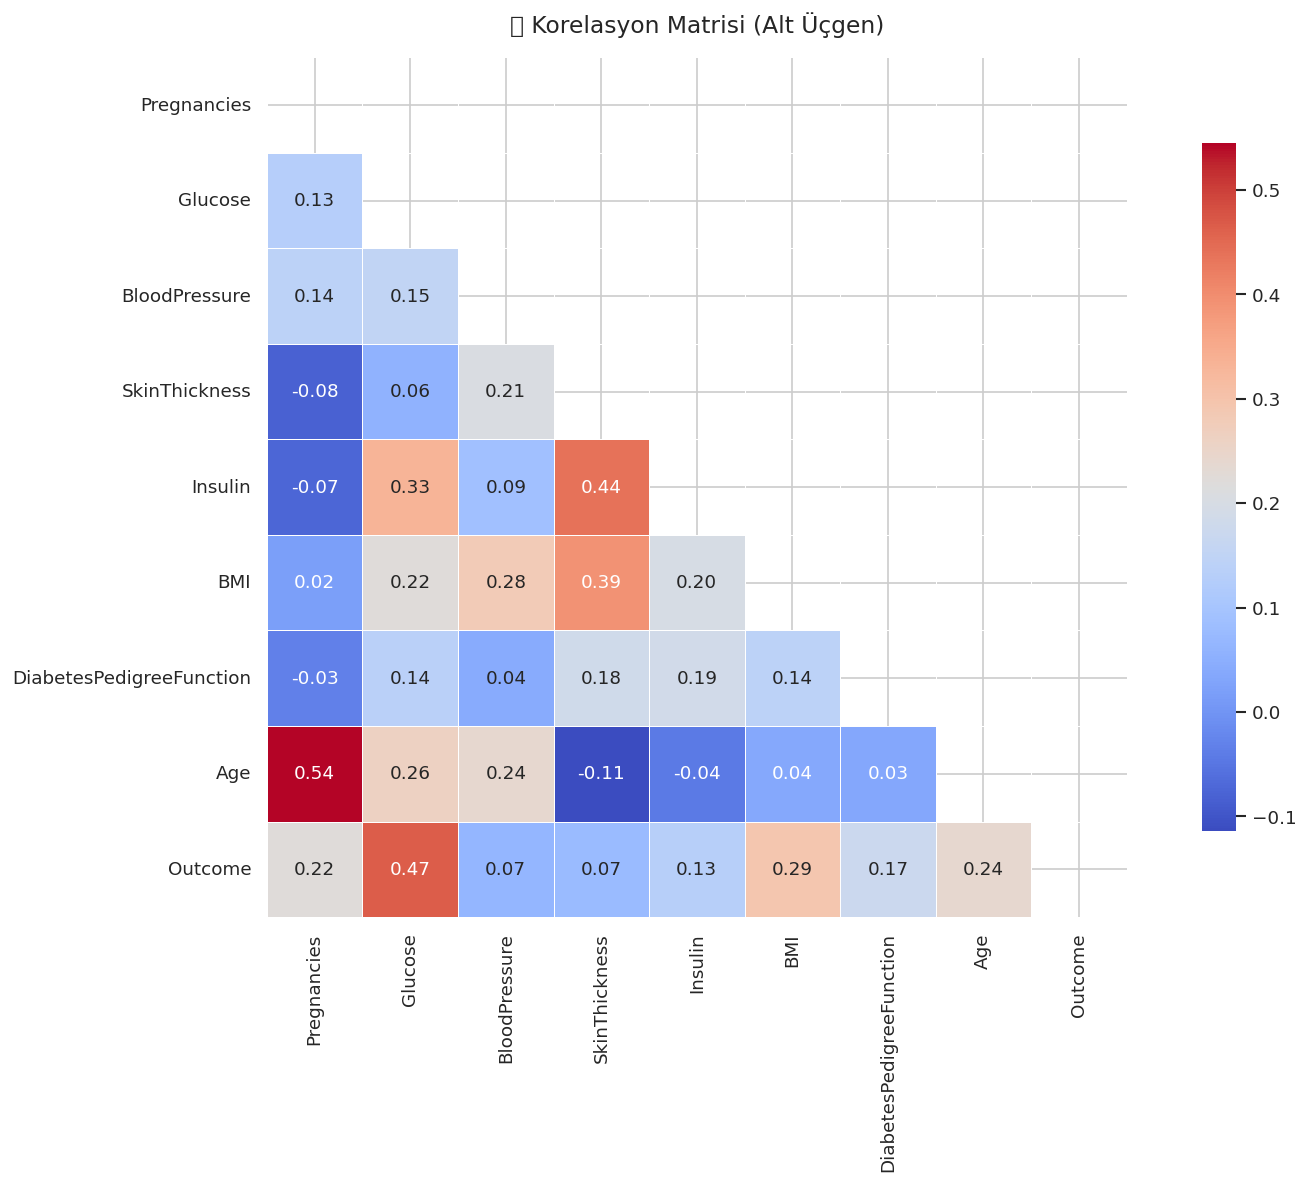

In [11]:
# Korelasyon matrisi
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))   # üçgen maskesi – okunabilirlik
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, mask=mask, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('🔗 Korelasyon Matrisi (Alt Üçgen)', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

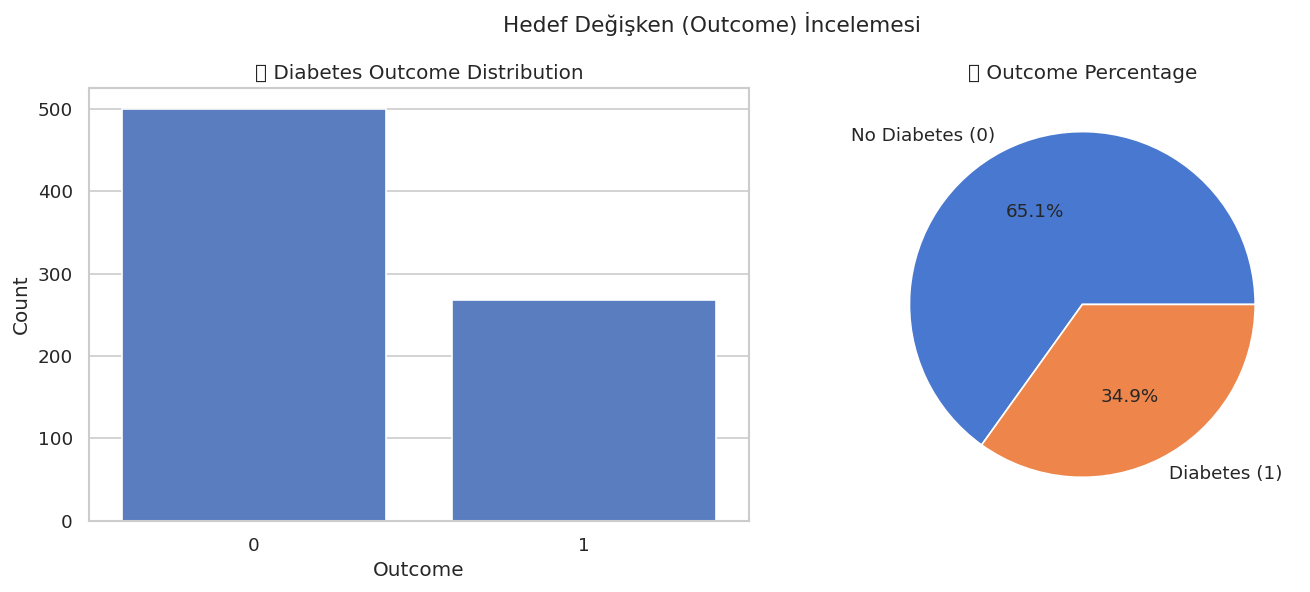

In [12]:
##    countplot → kategorik hedefler için daha uygun oldugundan histogram yerine tercih edildi!!!!
# Hedef değişken dağılımı
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Countplot
sns.countplot(x='Outcome', data=df, ax=axes[0])

axes[0].set_title('🏥 Diabetes Outcome Distribution')
axes[0].set_xlabel('Outcome')
axes[0].set_ylabel('Count')

# Pie chart
outcome_counts = df['Outcome'].value_counts()

axes[1].pie(
    outcome_counts,
    labels=['No Diabetes (0)', 'Diabetes (1)'],
    autopct='%1.1f%%'
)

axes[1].set_title('📊 Outcome Percentage')

plt.suptitle('Hedef Değişken (Outcome) İncelemesi', fontsize=13)

plt.tight_layout()
plt.show()

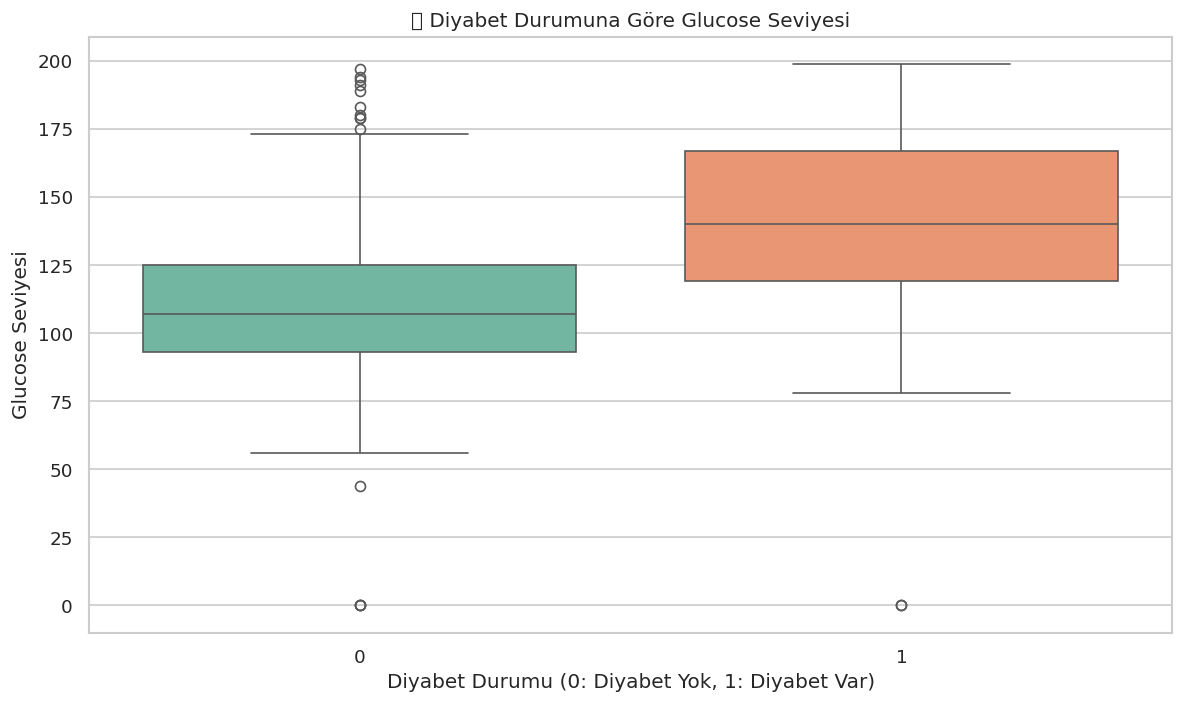

In [13]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='Outcome',
    y='Glucose',
    data=df,
    palette='Set2'
)

plt.title('🩸 Diyabet Durumuna Göre Glucose Seviyesi')
plt.xlabel('Diyabet Durumu (0: Diyabet Yok, 1: Diyabet Var)')
plt.ylabel('Glucose Seviyesi')

plt.tight_layout()
plt.show()

In [14]:
df_clean = df.copy()

# ADIM 1 — Gerçekte 0 olamayacak sütunlarda
# 0 değerlerini NaN yap
cols_with_zero_as_missing = [
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI'
]

df_clean[cols_with_zero_as_missing] = (
    df_clean[cols_with_zero_as_missing]
    .replace(0, np.nan)
)

# ADIM 2 — Sayısal eksik değerleri ortalama ile doldur
imputer = SimpleImputer(strategy='mean')

num_cols = df_clean.select_dtypes(include=[np.number]).columns

df_clean[num_cols] = imputer.fit_transform(df_clean[num_cols])

print("✅ Ön işleme tamamlandı.")
print(f"   Boyut        : {df_clean.shape}")
print(f"   Kalan eksik  : {df_clean.isnull().sum().sum()}")

✅ Ön işleme tamamlandı.
   Boyut        : (768, 9)
   Kalan eksik  : 0


# Random Forest Regresyon

In [15]:
# Özellik / hedef ayrımı

X_clf = df_clean.drop(columns=['Outcome'])
y_clf = df_clean['Outcome']

print(f"📌 Özellik sayısı : {X_clf.shape[1]}")
print(f"📌 Örnek sayısı   : {X_clf.shape[0]}")
print(f"📌 Özellikler     : {list(X_clf.columns)}")

📌 Özellik sayısı : 8
📌 Örnek sayısı   : 768
📌 Özellikler     : ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X_clf,
    y_clf,
    test_size=0.2,
    random_state=42,
    stratify=y_clf
)



print(f"🚂 Eğitim : {X_train.shape[0]:,} örnek")

print(f"🧪 Test   : {X_test.shape[0]:,} örnek")

🚂 Eğitim : 614 örnek
🧪 Test   : 154 örnek


In [20]:
rf_clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_clf.fit(X_train, y_train)

print("✅ Random Forest Sınıflandırma modeli eğitildi.")

✅ Random Forest Sınıflandırma modeli eğitildi.


In [21]:
y_pred = rf_clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("=" * 45)
print("  🏥 Sınıflandırma Modeli Performansı")
print("=" * 45)

print(f"  Accuracy : {accuracy:.4f} ({accuracy*100:.2f}%)")

print("=" * 45)

print("\n📋 Sınıflandırma Raporu:\n")

print(classification_report(y_test, y_pred))

  🏥 Sınıflandırma Modeli Performansı
  Accuracy : 0.7532 (75.32%)

📋 Sınıflandırma Raporu:

              precision    recall  f1-score   support

         0.0       0.79      0.85      0.82       100
         1.0       0.67      0.57      0.62        54

    accuracy                           0.75       154
   macro avg       0.73      0.71      0.72       154
weighted avg       0.75      0.75      0.75       154



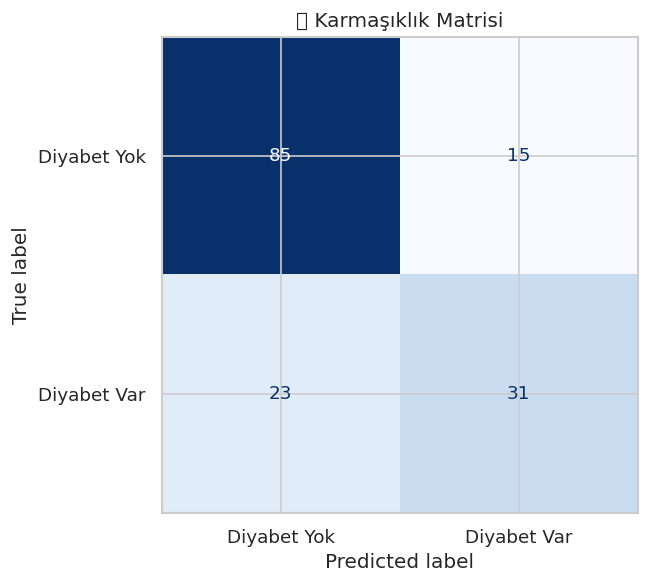

In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(6,5))

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Diyabet Yok', 'Diyabet Var']
)

disp.plot(cmap='Blues', ax=ax, colorbar=False)

ax.set_title('🔲 Karmaşıklık Matrisi')

plt.tight_layout()
plt.show()

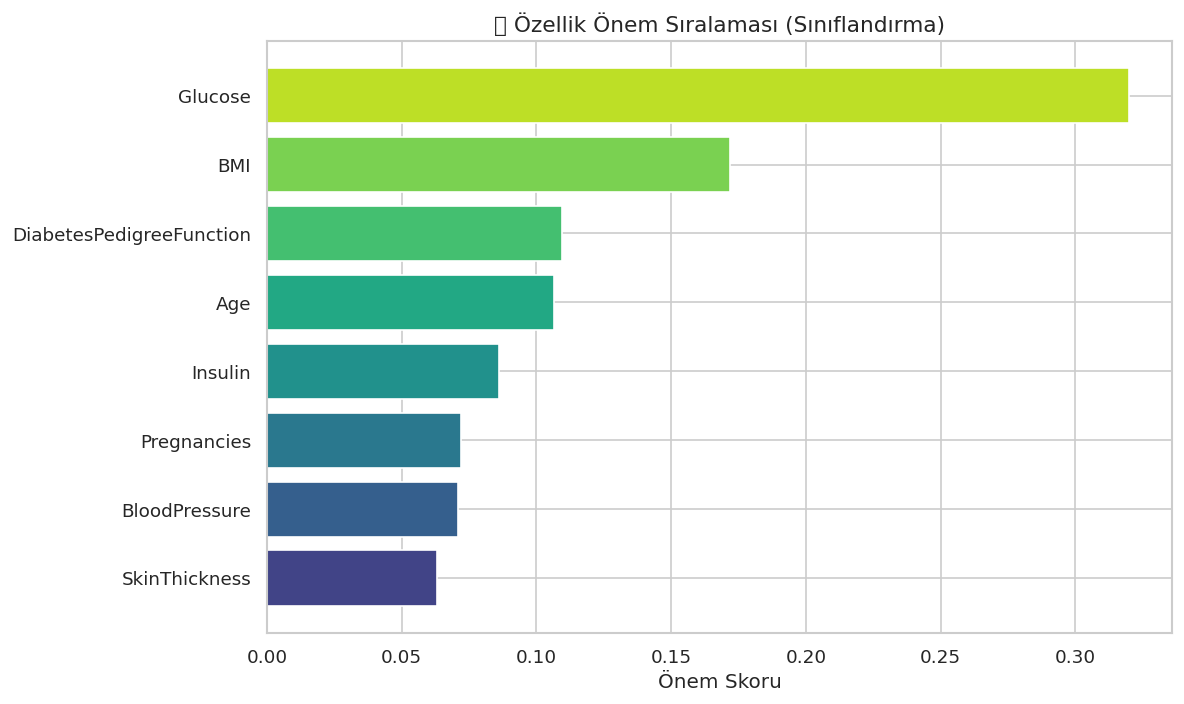


🔝 En Önemli 5 Özellik:
                 Özellik     Önem
                 Glucose 0.320054
                     BMI 0.171828
DiabetesPedigreeFunction 0.109583
                     Age 0.106577
                 Insulin 0.086247


In [23]:
feat_imp = pd.DataFrame({
    'Özellik': X_clf.columns,
    'Önem': rf_clf.feature_importances_
}).sort_values('Önem', ascending=True)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    feat_imp['Özellik'],
    feat_imp['Önem'],
    color=plt.cm.viridis(np.linspace(0.2, 0.9, len(feat_imp)))
)

plt.xlabel('Önem Skoru')
plt.title('🌟 Özellik Önem Sıralaması (Sınıflandırma)', fontsize=13)

plt.tight_layout()
plt.show()

print("\n🔝 En Önemli 5 Özellik:")

print(
    feat_imp
    .sort_values('Önem', ascending=False)
    .head(5)
    .to_string(index=False)
)

# GRID SEARCH

In [24]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(
    RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)

print("🔍 Grid Search başlıyor…")

grid_search.fit(X_train, y_train)

print(f"\n✅ En iyi parametreler : {grid_search.best_params_}")
print(f"   En iyi Accuracy (CV): {grid_search.best_score_:.4f}")

🔍 Grid Search başlıyor…

✅ En iyi parametreler : {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 50}
   En iyi Accuracy (CV): 0.7801


In [25]:
best_rf = grid_search.best_estimator_

y_pred_best = best_rf.predict(X_test)

accuracy_opt = accuracy_score(y_test, y_pred_best)

print("=" * 50)
print("  Temel Model vs Optimize Edilmiş Model")
print("=" * 50)

print(f"  Accuracy : {accuracy:.4f} → {accuracy_opt:.4f} "
      f"({'▲' if accuracy_opt >= accuracy else '▼'} "
      f"{abs(accuracy_opt - accuracy):.4f})")

print("=" * 50)

  Temel Model vs Optimize Edilmiş Model
  Accuracy : 0.7532 → 0.7597 (▲ 0.0065)


# Siniflandirma

🚂 Eğitim : 614 örnek
🧪 Test   : 154 örnek

📊 Sınıf Dağılımı (Eğitim):
Outcome
0.0    400
1.0    214
Name: count, dtype: int64
✅ Random Forest Sınıflandırma modeli eğitildi.
  🏥 Sınıflandırma Performansı
  Doğruluk (Accuracy): 0.7532 (75.32%)

📋 Sınıflandırma Raporu:

              precision    recall  f1-score   support

         0.0       0.79      0.85      0.82       100
         1.0       0.67      0.57      0.62        54

    accuracy                           0.75       154
   macro avg       0.73      0.71      0.72       154
weighted avg       0.75      0.75      0.75       154



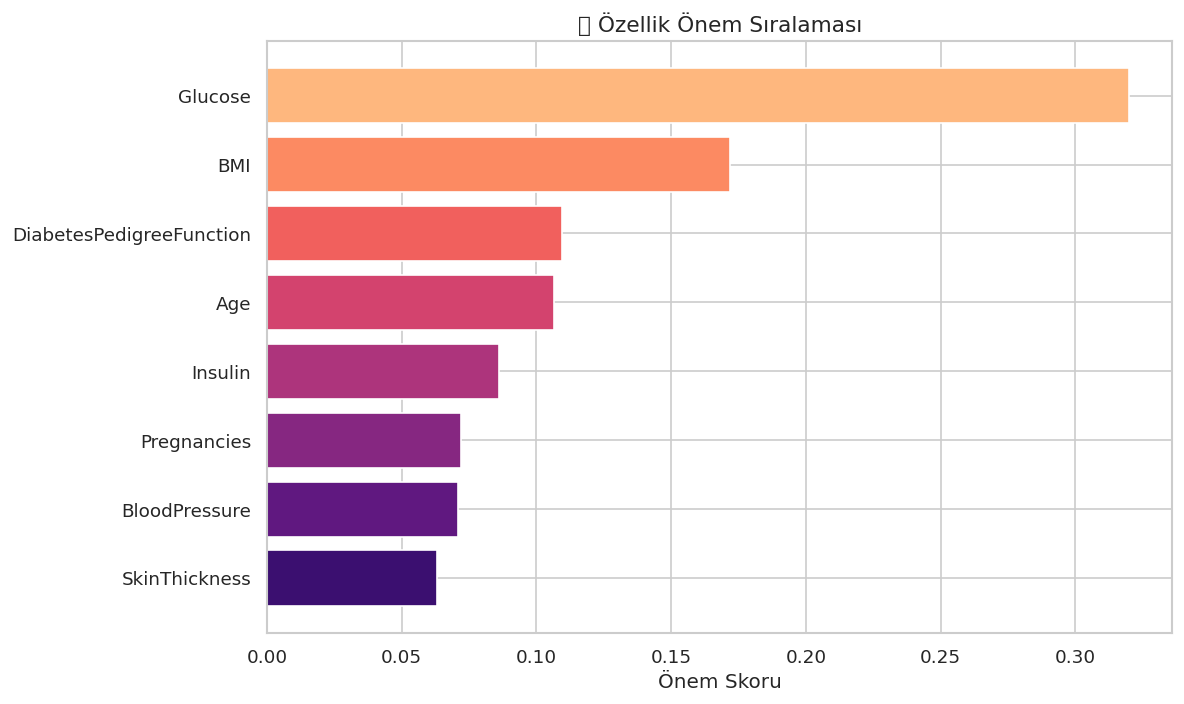


🔝 En Önemli 5 Özellik:
                 Özellik     Önem
                 Glucose 0.320054
                     BMI 0.171828
DiabetesPedigreeFunction 0.109583
                     Age 0.106577
                 Insulin 0.086247


In [27]:
# Özellik / hedef ayrımı
X_clf = df_clean.drop(columns=['Outcome'])
y_clf = df_clean['Outcome']

# Train / Test Split
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf,
    y_clf,
    test_size=0.2,
    random_state=42,
    stratify=y_clf
)

print(f"🚂 Eğitim : {X_train_clf.shape[0]:,} örnek")
print(f"🧪 Test   : {X_test_clf.shape[0]:,} örnek")

print("\n📊 Sınıf Dağılımı (Eğitim):")
print(y_train_clf.value_counts())


# Random Forest Classifier
rf_clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_clf.fit(X_train_clf, y_train_clf)

print("✅ Random Forest Sınıflandırma modeli eğitildi.")


# Tahmin
y_pred_clf = rf_clf.predict(X_test_clf)

accuracy = accuracy_score(y_test_clf, y_pred_clf)

print("=" * 45)
print("  🏥 Sınıflandırma Performansı")
print("=" * 45)

print(f"  Doğruluk (Accuracy): {accuracy:.4f} ({accuracy*100:.2f}%)")

print("=" * 45)

print("\n📋 Sınıflandırma Raporu:\n")

print(classification_report(y_test_clf, y_pred_clf))


# Feature Importance
feat_imp_clf = pd.DataFrame({
    'Özellik': X_clf.columns,
    'Önem': rf_clf.feature_importances_
}).sort_values('Önem', ascending=True)

plt.figure(figsize=(10, 6))

plt.barh(
    feat_imp_clf['Özellik'],
    feat_imp_clf['Önem'],
    color=plt.cm.magma(np.linspace(0.2, 0.85, len(feat_imp_clf)))
)

plt.xlabel('Önem Skoru')

plt.title('🌟 Özellik Önem Sıralaması', fontsize=13)

plt.tight_layout()
plt.show()


print("\n🔝 En Önemli 5 Özellik:")

print(
    feat_imp_clf
    .sort_values('Önem', ascending=False)
    .head(5)
    .to_string(index=False)
)

# Çapraz Doğrulama (5-Fold Cross Validation)

In [28]:
cv_scores = cross_val_score(
    rf_clf,
    X_clf,
    y_clf,
    cv=5,
    scoring='accuracy'
)

print("=== Sınıflandırma – 5-Fold CV ===")

for i, s in enumerate(cv_scores, 1):
    bar = '█' * int(s * 20)

    print(f"  Fold {i}: Accuracy = {s:.4f}  {bar}")

print(f"\n  Ortalama : {cv_scores.mean():.4f}")
print(f"  Std Dev  : {cv_scores.std():.4f}")

print(
    f"  95% CI   : "
    f"[{cv_scores.mean() - 2*cv_scores.std():.4f}, "
    f"{cv_scores.mean() + 2*cv_scores.std():.4f}]"
)

cv_scores_clf = cross_val_score(
    rf_clf,
    X_clf,
    y_clf,
    cv=5,
    scoring='accuracy'
)

print("=== Diyabet Sınıflandırması – 5-Fold CV ===")

for i, s in enumerate(cv_scores_clf, 1):

    bar = '█' * int(s * 20)

    print(f"  Fold {i}: Accuracy = {s:.4f}  {bar}")

print(f"\n  Ortalama Accuracy : {cv_scores_clf.mean():.4f}")
print(f"  Std Dev           : {cv_scores_clf.std():.4f}")

=== Sınıflandırma – 5-Fold CV ===
  Fold 1: Accuracy = 0.7468  ██████████████
  Fold 2: Accuracy = 0.7273  ██████████████
  Fold 3: Accuracy = 0.7532  ███████████████
  Fold 4: Accuracy = 0.8235  ████████████████
  Fold 5: Accuracy = 0.7582  ███████████████

  Ortalama : 0.7618
  Std Dev  : 0.0326
  95% CI   : [0.6966, 0.8270]
=== Diyabet Sınıflandırması – 5-Fold CV ===
  Fold 1: Accuracy = 0.7468  ██████████████
  Fold 2: Accuracy = 0.7273  ██████████████
  Fold 3: Accuracy = 0.7532  ███████████████
  Fold 4: Accuracy = 0.8235  ████████████████
  Fold 5: Accuracy = 0.7582  ███████████████

  Ortalama Accuracy : 0.7618
  Std Dev           : 0.0326


# Sonuç ve Değerlendirme

## 🏥 Diyabet Sınıflandırma Modeli (Outcome)

Bu çalışmada Random Forest algoritması kullanılarak diyabet veri seti üzerinde sınıflandırma analizi gerçekleştirilmiştir. Modelin amacı bireylerin diyabet durumunu (Outcome) tahmin etmektir.

Kurulan Random Forest modeli ile diyabet tahmini başarılı şekilde gerçekleştirilmiştir.

Model sonuçlarına göre:

- Temel model yaklaşık %75.32 doğruluk (Accuracy) elde etmiştir.
- Grid Search CV ile hiperparametre optimizasyonu yapıldıktan sonra doğruluk oranı %75.97 seviyesine yükselmiştir.
- 5-Fold Cross Validation sonucunda ortalama doğruluk değeri yaklaşık %76.18 olarak hesaplanmıştır.

Bu sonuçlar Random Forest algoritmasının diyabet tahmini probleminde başarılı performans gösterdiğini ortaya koymaktadır.

---

## 📊 Veri Analizi ve Görselleştirme

Çalışma kapsamında:

- Korelasyon matrisi oluşturuldu
- Outcome dağılımı incelendi
- Diyabet durumuna göre Glucose seviyeleri görselleştirildi
- Özellik önem (Feature Importance) analizi yapıldı
- Karmaşıklık Matrisi (Confusion Matrix) ile model performansı incelendi

Özellik önem analizine göre özellikle:

- Glucose
- BMI
- Age
- Insulin

değişkenlerinin model üzerinde daha etkili olduğu gözlemlendi.

---

## 🔍 Grid Search CV Sonuçları

Grid Search CV ile en iyi hiperparametre kombinasyonu aşağıdaki şekilde bulunmuştur:

- max_depth = 10
- min_samples_leaf = 4
- min_samples_split = 2
- n_estimators = 50

Bu optimizasyon sonucunda model performansında küçük fakat olumlu bir iyileşme elde edilmiştir.

---

## 🔁 Çapraz Doğrulama (Cross Validation)

5-Fold Cross Validation sonuçları modelin farklı veri bölünmelerinde tutarlı performans verdiğini göstermektedir.

- Ortalama Accuracy: 0.7618
- Standart Sapma: 0.0326

Düşük standart sapma değeri modelin kararlı çalıştığını göstermektedir.

---

## 🌲 Random Forest Algoritmasının Avantajları

- Yüksek doğruluk performansı
- Overfitting’e karşı dayanıklılık
- Özellik önem analizi sağlayabilmesi
- Gürültülü verilerde sağlam performans göstermesi
- Sağlık verileri üzerinde başarılı sonuçlar üretmesi
- Ölçeklendirme gerektirmeden çalışabilmesi

---

## 🎯 Genel Değerlendirme

Bu çalışma ile diyabet veri seti üzerinde başarılı bir makine öğrenimi sınıflandırma modeli geliştirilmiştir.

Veri analizi, görselleştirme, model eğitimi, hiperparametre optimizasyonu ve çapraz doğrulama adımları başarıyla uygulanmıştır.

Elde edilen sonuçlar Random Forest algoritmasının diyabet tahmini problemlerinde etkili ve güvenilir bir yöntem olduğunu göstermektedir.

# Random Forest ve Decision Tree Karşılaştırması

Aynı diyabet veri seti üzerinde hem Decision Tree hem de Random Forest algoritmaları uygulanmıştır. Sonuçlar karşılaştırıldığında Random Forest modelinin genel olarak daha başarılı performans gösterdiği görülmüştür.

## 📊 Accuracy Karşılaştırması

- Decision Tree Accuracy: 0.7273
- Random Forest Accuracy: 0.7532
- Optimize edilmiş Random Forest Accuracy: 0.7597

Random Forest modeli daha yüksek doğruluk oranı elde etmiştir.

---

## 📋 Precision / Recall / F1-Score Karşılaştırması

### Decision Tree

| Sınıf | Precision | Recall | F1-Score |
|---|---|---|---|
| 0 | 0.75 | 0.86 | 0.80 |
| 1 | 0.65 | 0.48 | 0.55 |

### Random Forest

| Sınıf | Precision | Recall | F1-Score |
|---|---|---|---|
| 0 | 0.79 | 0.85 | 0.82 |
| 1 | 0.67 | 0.57 | 0.62 |

Random Forest modeli özellikle diyabet olan bireyleri temsil eden “1” sınıfında daha iyi sonuç vermiştir. Recall değerinin 0.48’den 0.57’ye yükselmesi modelin diyabet hastalarını daha başarılı tespit ettiğini göstermektedir.

---

## 🌲 Model Yapısı Farkı

- Decision Tree tek bir karar ağacından oluşmaktadır.
- Random Forest ise çok sayıda karar ağacının birleşiminden oluşan ensemble bir yöntemdir.

Bu nedenle Random Forest:
- Daha kararlı sonuçlar üretmiştir
- Overfitting riskini azaltmıştır
- Daha yüksek genelleme performansı göstermiştir

---

## 🎯 Genel Sonuç

Çıktılara göre Random Forest modeli hem accuracy hem de precision/recall değerlerinde Decision Tree modelinden daha başarılı sonuçlar vermiştir. Özellikle diyabetli bireylerin tespitinde daha dengeli ve güvenilir performans göstermiştir.